# Pair Trading of GLD and GDX

In [89]:
import numpy as np

In [90]:
import pandas as pd

In [91]:
import matplotlib.pyplot as plt

In [92]:
import statsmodels.api as sm

In [93]:
import yfinance as yf

def download_prices(symbol, start='2006-05-22', end='2026-01-01'):
    data = yf.download(symbol, start=start, end=end, auto_adjust=False)
    data.columns = data.columns.get_level_values(0)  # drop ticker level
    return data.reset_index()

df1=download_prices('GLD')

[*********************100%***********************]  1 of 1 completed


In [94]:
df2=download_prices('GDX')

[*********************100%***********************]  1 of 1 completed

In [95]:
df=pd.merge(df1, df2, on='Date', suffixes=('_GLD', '_GDX'))

In [96]:
df.set_index('Date', inplace=True)

In [97]:
df.sort_index(inplace=True)

In [98]:
trainEnd=(df.index < '2024-01-01').sum() # trainset: start of data until end of 2023, testset: 2024 until 2025
trainset=np.arange(0, trainEnd)

In [99]:
testset=np.arange(trainset.shape[0], df.shape[0])

## Determine hedge ratio on trainset

In [100]:
model=sm.OLS(df.loc[:, 'Adj Close_GLD'].iloc[trainset], df.loc[:, 'Adj Close_GDX'].iloc[trainset])

In [101]:
results=model.fit()

In [102]:
hedgeRatio=results.params

In [103]:
hedgeRatio

Adj Close_GDX    3.896428
dtype: float64

##  spread = GLD - hedgeRatio*GDX

In [104]:
spread=df.loc[:, 'Adj Close_GLD']-hedgeRatio.iloc[0]*df.loc[:, 'Adj Close_GDX']

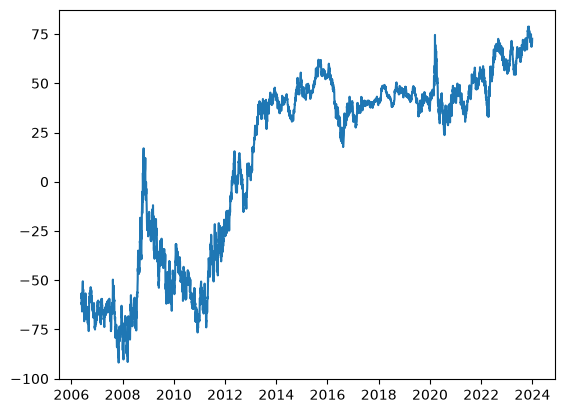

In [105]:
plt.plot(spread.iloc[trainset])

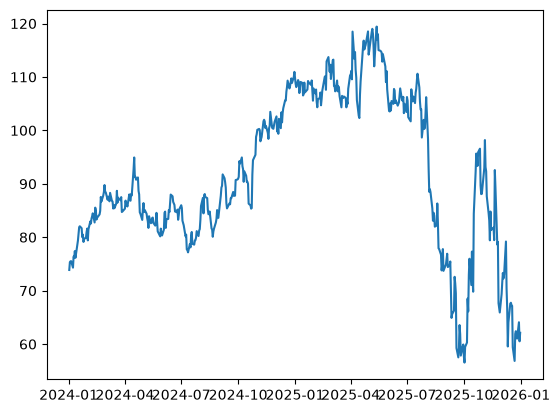

In [106]:
plt.plot(spread.iloc[testset])

In [107]:
spreadMean=np.mean(spread.iloc[trainset])

In [108]:
spreadMean

np.float64(11.342812074196551)

In [109]:
spreadStd=np.std(spread.iloc[trainset])

In [110]:
spreadStd

np.float64(47.25564025681581)

In [111]:
df['zscore']=(spread-spreadMean)/spreadStd

In [112]:
df['positions_GLD_Long']=np.nan

In [113]:
df['positions_GDX_Long']=np.nan

In [114]:
df['positions_GLD_Short']=np.nan

In [115]:
df['positions_GDX_Short']=np.nan

In [ ]:
df.loc[df.zscore>=1.75, ('positions_GLD_Short', 'positions_GDX_Short')]=[-1, 1] # Short spread

In [ ]:
df.loc[df.zscore<=-1.75, ('positions_GLD_Long', 'positions_GDX_Long')]=[1, -1] # Buy spread

In [118]:
df.loc[df.zscore<=0.5, ('positions_GLD_Short', 'positions_GDX_Short')]=0 # Exit short spread

In [119]:
df.loc[df.zscore>=-0.5, ('positions_GLD_Long', 'positions_GDX_Long')]=0 # Exit long spread

In [120]:
posCols=[c for c in df.columns if c.startswith('positions_')]
df[posCols]=df[posCols].ffill().fillna(0) # carry existing positions forward unless there is an exit signal; no position before the first signal

In [121]:
positions_Long=df.loc[:, ('positions_GLD_Long', 'positions_GDX_Long')]

In [122]:
positions_Short=df.loc[:, ('positions_GLD_Short', 'positions_GDX_Short')]

In [123]:
positions=np.array(positions_Long)+np.array(positions_Short)

In [124]:
positions=pd.DataFrame(positions)

In [125]:
dailyret=df.loc[:, ('Adj Close_GLD', 'Adj Close_GDX')].pct_change()

In [126]:
pnl=(np.array(positions.shift())*np.array(dailyret)).sum(axis=1)

In [127]:
sharpeTrainset=np.sqrt(252)*np.mean(pnl[trainset[1:]])/np.std(pnl[trainset[1:]])

In [128]:
sharpeTrainset

np.float64(0.43515292173852416)

In [129]:
sharpeTestset=np.sqrt(252)*np.mean(pnl[testset])/np.std(pnl[testset])

In [130]:
sharpeTestset

np.float64(0.8733089235037035)

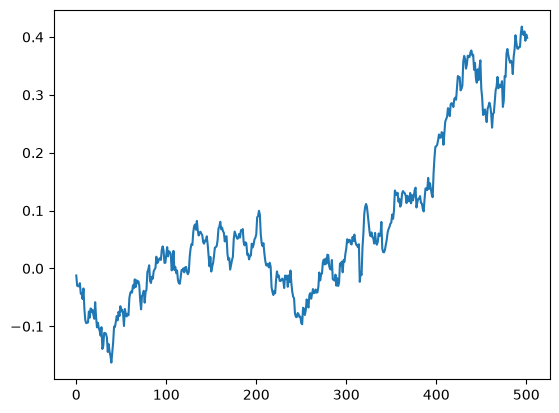

In [131]:
plt.plot(np.cumsum(pnl[testset]))

In [132]:
positions.to_pickle('example3_6_positions')